<a href="https://colab.research.google.com/github/hamza-6969/Live-Fifa-World-Cup-Sentiment-Analysis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## FIFA Tweet Sentiment Analysis Pipeline

This notebook builds a sentiment analysis pipeline for FIFA World Cup tweets.

First, the tweet datasets are extracted and loaded into pandas DataFrames. The data is cleaned by keeping only English tweets and removing missing tweet content. A pretrained Hugging Face Twitter-RoBERTa sentiment model is then used to automatically generate sentiment labels for unlabeled tweets.

The generated labels are combined with an existing labeled FIFA tweet dataset to create a larger training dataset. The tweet text is preprocessed by removing special characters, converting text to lowercase, removing stopwords, and applying Porter stemming.

After preprocessing, the tweets are converted into numerical features using TF-IDF vectorization. A Logistic Regression model is trained on these features to classify tweets as positive, negative, or neutral. The model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

Finally, the trained sentiment model and TF-IDF vectorizer are saved as pickle files so they can be reused later for prediction or deployment.

# **Test Resullts**

Accuracy: 86.44%

Classification Report:              precision    recall  f1-score   support


    negative       0.86      0.78      0.82      2598
    neutral        0.84      0.86      0.85      6226
    positive       0.89      0.90      0.89      7471

    accuracy         NA        NA       0.86     16295
    macro avg       0.86      0.84      0.85     16295
    weighted avg    0.86      0.86      0.86     16295


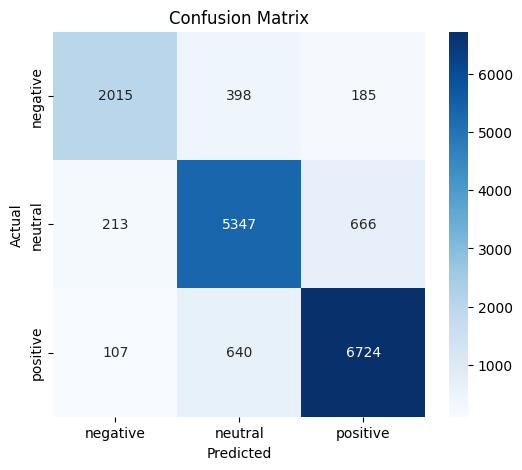

In [1]:
import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
from zipfile import ZipFile

with ZipFile("/content/archive (1).zip","r") as zp :
  zp.extractall()
  print("Dataset 1 extracted")
with ZipFile("/content/fifa_world_cup_2022_tweets.csv.zip","r") as zp :
  zp.extractall()
  print("Dataset 2 extracted")

Dataset 1 extracted
Dataset 2 extracted


In [5]:
df1 = pd.read_excel("/content/tweets1.xlsx")
df2 = pd.read_excel("/content/tweets2.xlsx")

combined_df = pd.concat([df1,df2],ignore_index = True)


,Tweet Id,Tweet URL,Tweet Posted Time,Tweet Content,Tweet Type,Client,Retweets Received,Likes Received,Tweet Location,Tweet Language,User Id,Name,Username,User Bio,Verified or Non-Verified,Profile URL,User Followers,User Following,User Account Creation Date
0,"""1603309229871452160""",https://twitter.com/imrmkhan1/status/160330922...,15 Dec 2022 08:41:23,"""Field par Messi aur Mbappe… studio mein @Wayn...",ReTweet,"""Twitter for Android""",0,0,"""""",Hindi,"""1584973275628699648""","""iamrmkhan""",imrmkhan1,"""""",Non-Verified,https://twitter.com/imrmkhan1,11,12,25-Oct-2022 18:21:42
1,"""1603309229980487681""",https://twitter.com/Shahxaze1/status/160330922...,15 Dec 2022 08:41:23,"""𝐈𝐭. 𝐂𝐚𝐧𝐧𝐨𝐭. 𝐆𝐞𝐭. 𝐁𝐢𝐠𝐠𝐞𝐫. 𝐓𝐡𝐚𝐧. 𝐓𝐡𝐢𝐬. 🔥\n\nGet...",ReTweet,"""Twitter for iPhone""",0,0,"""""",English,"""1558508894925869056""","""Shahxaze""",Shahxaze1,"""Shah Rukh Khan Aze 🇦🇿""",Non-Verified,https://twitter.com/Shahxaze1,247,232,13-Aug-2022 17:41:00
2,"""1603309226469642240""",https://twitter.com/SorareAlexandre/status/160...,15 Dec 2022 08:41:22,"""🎁 CONCOURS SORARE 🎁\n\nJOUEUR À GAGNER : SEKO...",ReTweet,"""Twitter for Android""",0,0,"""""",French,"""1592150953871958016""","""Pawastyle45""",SorareAlexandre,"""Je viens de découvrir Sorare et je surkiffe. ...",Non-Verified,https://twitter.com/SorareAlexandre,18,154,14-Nov-2022 13:42:50
3,"""1603309226604236800""",https://twitter.com/Woozie178/status/160330922...,15 Dec 2022 08:41:22,"""It’ll be a tough night for Europe today.\n\n#...",ReTweet,"""Twitter for Android""",0,0,"""""",English,"""1492945970295808003""","""Woozie""",Woozie178,"""Truth seeker, nationalist, engineer, gamer""",Non-Verified,https://twitter.com/Woozie178,19,131,13-Feb-2022 19:37:47
4,"""1603309227392618496""",https://twitter.com/thug_boiiii/status/1603309...,15 Dec 2022 08:41:22,"""In defeat or in victory, always say Alhamduli...",ReTweet,"""Twitter for Android""",0,0,"""""",English,"""999001409231212544""","""Itx_madan 🇵🇰💪🇵🇸""",thug_boiiii,"""Content Creator.......https://www.instagram.c...",Non-Verified,https://twitter.com/thug_boiiii,803,778,22-May-2018 18:57:51


In [7]:
df_tweets = combined_df[
    (combined_df["Tweet Language"] == "English") &
    (combined_df["Tweet Content"].notna())
]["Tweet Content"]

df_tweets.head()

,Tweet Content
1,"""𝐈𝐭. 𝐂𝐚𝐧𝐧𝐨𝐭. 𝐆𝐞𝐭. 𝐁𝐢𝐠𝐠𝐞𝐫. 𝐓𝐡𝐚𝐧. 𝐓𝐡𝐢𝐬. 🔥\n\nGet..."
3,"""It’ll be a tough night for Europe today.\n\n#..."
4,"""In defeat or in victory, always say Alhamduli..."
5,"""FAFC Genesis Edition ( This collection have m..."
6,"""Get ready for zabardast action on #25th Jan ...."


In [4]:
#Importing hugging_face transformer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import pandas as pd

MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [12]:
import torch

labels = ["Negative", "Neutral", "Positive"]

def predict_sentiment (list_of_tweets):

    encoded = tokenizer(
        list_of_tweets,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding = True
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        output = model(**encoded)

    predictions = torch.argmax(output.logits,dim = 1)

    return [labels[p.item()] for p in predictions]




In [15]:
df_tweets_list = df_tweets.tolist()

all_sentiments = []
predictions = []
batch_size = 64
for i in range(0,len(df_tweets_list),batch_size):
  batch = df_tweets_list[i:i+ batch_size]
  predictions = predict_sentiment(batch)
  all_sentiments.extend(predictions)

df_tweets = df_tweets.copy()
df_tweets["Sentiment"] = all_sentiments
#print(len(tweet_data))
print(len(all_sentiments))


58951


In [20]:
final_df = pd.DataFrame({"Tweet Data": df_tweets_list, "Sentiments" : all_sentiments})
final_df.head()

,Tweet Data,Sentiments
0,"""𝐈𝐭. 𝐂𝐚𝐧𝐧𝐨𝐭. 𝐆𝐞𝐭. 𝐁𝐢𝐠𝐠𝐞𝐫. 𝐓𝐡𝐚𝐧. 𝐓𝐡𝐢𝐬. 🔥\n\nGet...",Neutral
1,"""It’ll be a tough night for Europe today.\n\n#...",Neutral
2,"""In defeat or in victory, always say Alhamduli...",Positive
3,"""FAFC Genesis Edition ( This collection have m...",Neutral
4,"""Get ready for zabardast action on #25th Jan ....",Positive


In [21]:
#handling the 2nd data csv

dataset2= pd.read_csv("/content/fifa_world_cup_2022_tweets.csv")
dataset2.head()



,Unnamed: 0,Date Created,Number of Likes,Source of Tweet,Tweet,Sentiment
0,0,2022-11-20 23:59:21+00:00,4,Twitter Web App,What are we drinking today @TucanTribe \n@MadB...,neutral
1,1,2022-11-20 23:59:01+00:00,3,Twitter for iPhone,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,positive
2,2,2022-11-20 23:58:41+00:00,1,Twitter for iPhone,Worth reading while watching #WorldCup2022 htt...,positive
3,3,2022-11-20 23:58:33+00:00,1,Twitter Web App,Golden Maknae shinning bright\n\nhttps://t.co/...,positive
4,4,2022-11-20 23:58:28+00:00,0,Twitter for Android,"If the BBC cares so much about human rights, h...",negative


In [24]:
dataset2 = dataset2.loc[dataset2["Tweet"].notna(), ["Tweet", "Sentiment"]]
dataset2.head()

,Tweet,Sentiment
0,What are we drinking today @TucanTribe \n@MadB...,neutral
1,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,positive
2,Worth reading while watching #WorldCup2022 htt...,positive
3,Golden Maknae shinning bright\n\nhttps://t.co/...,positive
4,"If the BBC cares so much about human rights, h...",negative


In [37]:
dataset2 = dataset2.rename(columns={
    "Tweet Content": "tweet",
    "Sentiments": "sentiment"
})

final_df = final_df.rename(columns={
    "Tweet Data": "tweet",
    "Sentiments": "sentiment"   # adjust this if your exact column name is different
})

training_df = pd.concat([final_df,dataset2],ignore_index=True)
training_df.head()


(81475, 2)


,count
sentiment,
Positive,28865
Neutral,22881
positive,8489
neutral,8251
Negative,7205
negative,5784


In [39]:
training_df= training_df.replace({"Positive":"positive","Negative":"negative","Neutral":"neutral"})
training_df["sentiment"].value_counts()

,count
sentiment,
positive,37354
neutral,31132
negative,12989


In [40]:
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

port_stem = PorterStemmer()
english_stopwords = set(stopwords.words("english"))

def stemming(content):
    content = str(content)
    stemmed_content = re.sub("[^a-zA-Z]", " ", content)
    stemmed_content = stemmed_content.lower().split()
    stemmed_content = [
        port_stem.stem(word)
        for word in stemmed_content
        if word not in english_stopwords
    ]
    return " ".join(stemmed_content)

training_df["tweet"] = training_df["tweet"].astype(str).apply(stemming)

In [41]:
X = training_df["tweet"]
Y = training_df["sentiment"]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size = 0.2 , stratify = Y, random_state= 2)


#convert our textual tweet data into vectors(numbers) so that model understands

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train,Y_train)


LogisticRegression(max_iter=1000)

In [43]:
X_prediction = model.predict(X_test)
score = accuracy_score(Y_test, X_prediction)
print(f"The model has a accuracy score of {score*100}%")

The model has a accuracy score of 86.44369438478061%


Accuracy: 86.44%

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.78      0.82      2598
     neutral       0.84      0.86      0.85      6226
    positive       0.89      0.90      0.89      7471

    accuracy                           0.86     16295
   macro avg       0.86      0.84      0.85     16295
weighted avg       0.86      0.86      0.86     16295



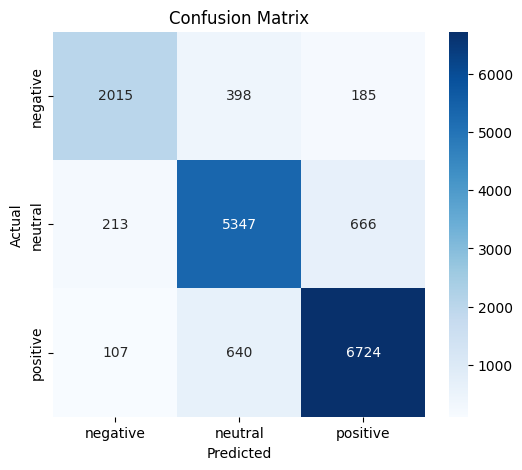

In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# 1. Accuracy
score = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {score * 100:.2f}%")

# 2. Precision, Recall, F1
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

# 3. Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Accuracy: 86.44%

Classification Report:              precision    recall  f1-score   support


    negative       0.86      0.78      0.82      2598
    neutral        0.84      0.86      0.85      6226
    positive       0.89      0.90      0.89      7471

    accuracy         NA        NA       0.86     16295
    macro avg       0.86      0.84      0.85     16295
    weighted avg    0.86      0.86      0.86     16295


In [45]:
sample_tweets = [
    "What a fantastic goal, brilliant match!",
    "That was the worst referee decision ever.",
    "Decent game, nothing special."
]

sample_tweets_stemmed = [stemming(tweet) for tweet in sample_tweets]
sample_vectors = vectorizer.transform(sample_tweets_stemmed)
sample_predictions = model.predict(sample_vectors)

for tweet, pred in zip(sample_tweets, sample_predictions):
    print(tweet, "->", pred)

What a fantastic goal, brilliant match! -> positive
That was the worst referee decision ever. -> negative
Decent game, nothing special. -> positive


In [46]:
import pickle

# Save trained model
with open("sentiment_model.pkl", "wb") as file:
    pickle.dump(model, file)

# Save vectorizer/tokenizer too if your model uses one
with open("vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

In [47]:
from google.colab import files

files.download("sentiment_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>